In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
appearances = pd.read_csv(r"E:\FOOTBALL RARITY PROJECT\appearances.csv")
players = pd.read_csv(r"E:\FOOTBALL RARITY PROJECT\playas.csv")
games = pd.read_csv(r"E:\FOOTBALL RARITY PROJECT\games.csv")
competitions = pd.read_csv(r"E:\FOOTBALL RARITY PROJECT\competitions.csv")


Merged dataframe shape: (1885697, 17)
    appearance_id  game_id  player_id  player_club_id  player_current_club_id  \
0   2231978_38004  2231978      38004             853                     235   
1   2233748_79232  2233748      79232            8841                    2698   
2   2234413_42792  2234413      42792            6251                     465   
3   2234418_73333  2234418      73333            1274                      76   
4  2234421_122011  2234421     122011             195                    3008   

         date       player_name competition_id_x  yellow_cards  red_cards  \
0  2012-07-03  Aurélien Joachim              CLQ             0          0   
1  2012-07-05    Ruslan Abyshov              ELQ             0          0   
2  2012-07-05       Sander Puri              ELQ             0          0   
3  2012-07-05   Vegar Hedenstad              ELQ             0          0   
4  2012-07-05  Markus Henriksen              ELQ             0          0   

   goals  a

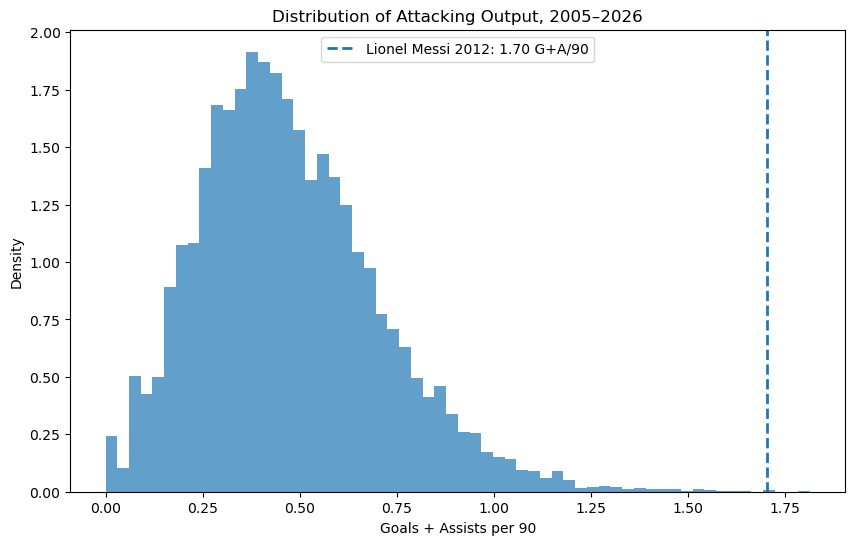

No data found for: Neymar


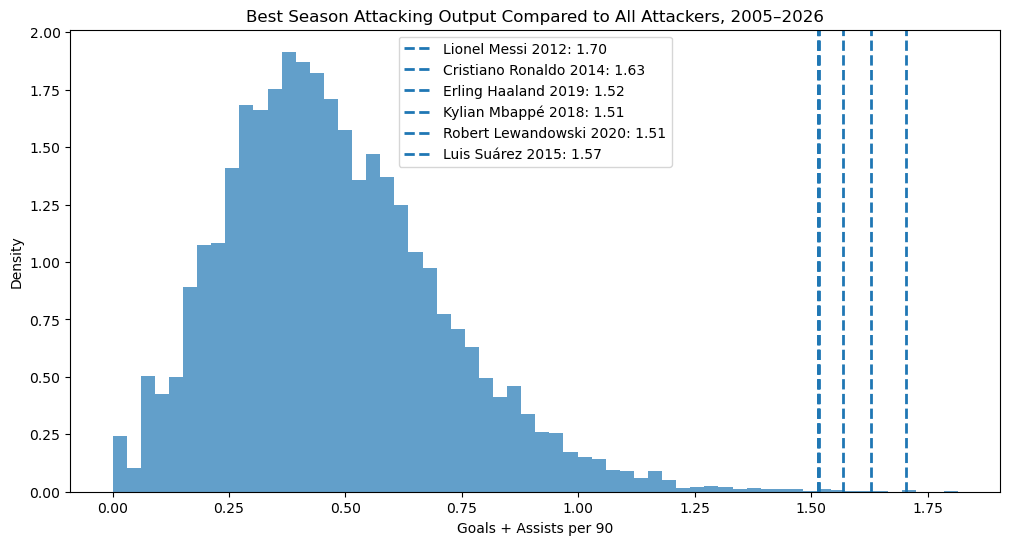


================ PLAYER COMPARISON ================
               Player  Best Season  G+A per 90   z-score  \
0        Lionel Messi         2012    1.702703  5.247461   
1   Cristiano Ronaldo         2014    1.628959  4.932069   
5         Luis Suárez         2015    1.567352  4.668581   
2      Erling Haaland         2019    1.516245  4.450004   
3       Kylian Mbappé         2018    1.514851  4.444042   
4  Robert Lewandowski         2020    1.513721  4.439207   

   Empirical Probability Empirical Rarity  
0               0.000221       1 in 4,534  
1               0.000515       1 in 1,943  
5               0.000735       1 in 1,360  
2               0.001029         1 in 971  
3               0.001103         1 in 907  
4               0.001176         1 in 850  


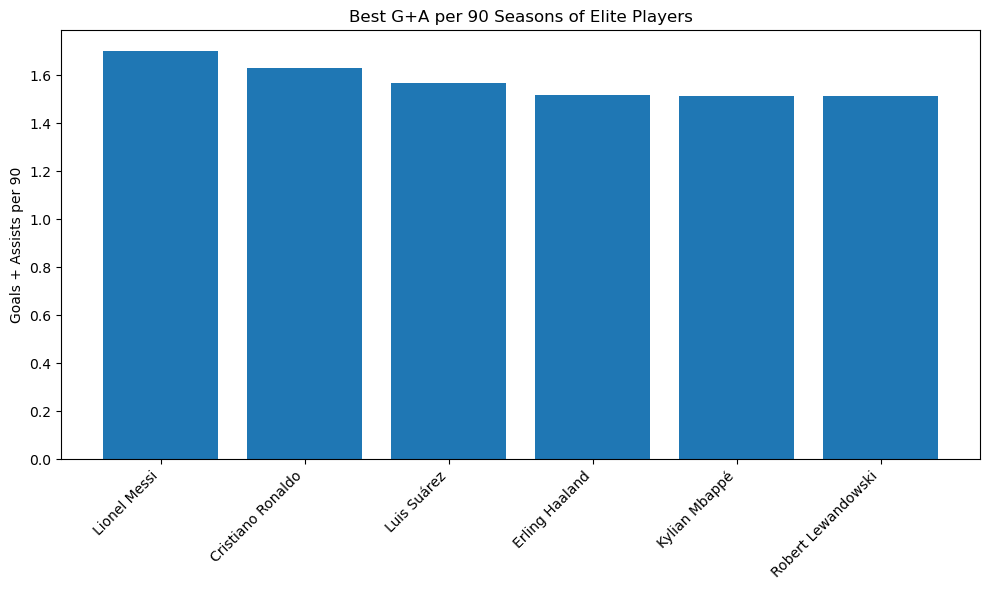

In [4]:

# ============================================================
# 2. MERGE APPEARANCES + GAMES
# ============================================================

df = appearances.merge(
    games[["game_id", "season", "competition_id"]],
    on="game_id",
    how="left"
)

# ============================================================
# 3. MERGE WITH PLAYER INFORMATION
# ============================================================

df = df.merge(
    players[["player_id", "name", "position"]],
    on="player_id",
    how="left"
)

print("\nMerged dataframe shape:", df.shape)
print(df.head())


# ============================================================
# 4. KEEP SEASONS FROM 2005 TO 2026
# ============================================================

df = df[(df["season"] >= 2005) & (df["season"] <= 2026)]

print("\nSeason range:")
print(df["season"].min(), "to", df["season"].max())


# ============================================================
# 5. CREATE GOALS + ASSISTS
# ============================================================

df["GA"] = df["goals"] + df["assists"]

print("\nSample after creating GA:")
print(df[["name", "season", "goals", "assists", "GA", "minutes_played"]].head())


# ============================================================
# 6. AGGREGATE BY PLAYER AND SEASON
# ============================================================

season_stats = df.groupby(
    ["player_id", "name", "position", "season"],
    as_index=False
).agg({
    "goals": "sum",
    "assists": "sum",
    "GA": "sum",
    "minutes_played": "sum",
    "game_id": "count"
})

season_stats = season_stats.rename(columns={
    "game_id": "appearances"
})

# Remove players with very low minutes
season_stats = season_stats[season_stats["minutes_played"] >= 900]

# Calculate G+A per 90
season_stats["ninety_minutes"] = season_stats["minutes_played"] / 90
season_stats["GA_per90"] = season_stats["GA"] / season_stats["ninety_minutes"]

print("\nSeason-level dataset:")
print(season_stats.head())

print("\nSeason stats shape:", season_stats.shape)


# ============================================================
# 7. FILTER ATTACKERS
# ============================================================

attackers = season_stats[
    season_stats["position"].str.contains(
        "Attack|Forward|Centre-Forward|Winger|Second Striker|Left Winger|Right Winger",
        case=False,
        na=False
    )
].copy()

print("\nAttackers dataset shape:", attackers.shape)

print("\nAttacker positions found:")
print(attackers["position"].value_counts().head(20))


# ============================================================
# 8. FIND ONE PLAYER'S BEST SEASON
# ============================================================

player_name = "Messi"

player_rows = attackers[
    attackers["name"].str.contains(player_name, case=False, na=False)
].sort_values("GA_per90", ascending=False)

print(f"\nBest seasons found for {player_name}:")
print(player_rows[["name", "season", "position", "minutes_played", "goals", "assists", "GA", "GA_per90"]].head(10))


# ============================================================
# 9. CALCULATE RARITY FOR THAT PLAYER
# ============================================================

if player_rows.empty:
    print(f"\nNo player found matching: {player_name}")
else:
    player_value = player_rows["GA_per90"].iloc[0]
    player_season = player_rows["season"].iloc[0]
    player_full_name = player_rows["name"].iloc[0]

    mu = attackers["GA_per90"].mean()
    sd = attackers["GA_per90"].std()

    z = (player_value - mu) / sd

    normal_prob = 1 - norm.cdf(z)
    empirical_prob = (attackers["GA_per90"] >= player_value).mean()

    print("\n================ RARITY RESULT ================")
    print(f"Player: {player_full_name}")
    print(f"Best season: {player_season}")
    print(f"G+A per 90 = {player_value:.3f}")
    print(f"Dataset mean = {mu:.3f}")
    print(f"Dataset standard deviation = {sd:.3f}")
    print(f"z-score = {z:.2f}σ above average")
    print()

    print(f"Normal probability = {normal_prob:.10f}")
    if normal_prob > 0:
        print(f"Normal rarity ≈ 1 in {1 / normal_prob:,.0f}")

    print()

    print(f"Empirical probability = {empirical_prob:.10f}")
    if empirical_prob > 0:
        print(f"Empirical rarity ≈ 1 in {1 / empirical_prob:,.0f}")


    # ============================================================
    # 10. VISUALIZE DISTRIBUTION FOR ONE PLAYER
    # ============================================================

    plt.figure(figsize=(10, 6))

    plt.hist(
        attackers["GA_per90"],
        bins=60,
        density=True,
        alpha=0.7
    )

    plt.axvline(
        player_value,
        linestyle="--",
        linewidth=2,
        label=f"{player_full_name} {player_season}: {player_value:.2f} G+A/90"
    )

    plt.xlabel("Goals + Assists per 90")
    plt.ylabel("Density")
    plt.title("Distribution of Attacking Output, 2005–2026")
    plt.legend()
    plt.show()


# ============================================================
# 11. COMPARE MULTIPLE ELITE PLAYERS
# ============================================================

players_to_compare = [
    "Messi",
    "Cristiano Ronaldo",
    "Haaland",
    "Mbapp",
    "Lewandowski",
    "Neymar",
    "Suárez"
]

plt.figure(figsize=(12, 6))

plt.hist(
    attackers["GA_per90"],
    bins=60,
    density=True,
    alpha=0.7
)

comparison_results = []

for p in players_to_compare:
    rows = attackers[
        attackers["name"].str.contains(p, case=False, na=False)
    ].sort_values("GA_per90", ascending=False)

    if not rows.empty:
        best_value = rows["GA_per90"].iloc[0]
        best_season = rows["season"].iloc[0]
        full_name = rows["name"].iloc[0]

        z_score = (best_value - attackers["GA_per90"].mean()) / attackers["GA_per90"].std()
        empirical_probability = (attackers["GA_per90"] >= best_value).mean()

        comparison_results.append({
            "Player": full_name,
            "Best Season": best_season,
            "G+A per 90": best_value,
            "z-score": z_score,
            "Empirical Probability": empirical_probability,
            "Empirical Rarity": f"1 in {1 / empirical_probability:,.0f}" if empirical_probability > 0 else "Undefined"
        })

        plt.axvline(
            best_value,
            linestyle="--",
            linewidth=2,
            label=f"{full_name} {best_season}: {best_value:.2f}"
        )
    else:
        print(f"No data found for: {p}")

plt.xlabel("Goals + Assists per 90")
plt.ylabel("Density")
plt.title("Best Season Attacking Output Compared to All Attackers, 2005–2026")
plt.legend()
plt.show()


# ============================================================
# 12. DISPLAY COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(comparison_results)

print("\n================ PLAYER COMPARISON ================")
print(comparison_df.sort_values("G+A per 90", ascending=False))


# ============================================================
# 13. OPTIONAL: BAR CHART OF ELITE PLAYERS
# ============================================================

if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("G+A per 90", ascending=False)

    plt.figure(figsize=(10, 6))

    plt.bar(
        comparison_df["Player"],
        comparison_df["G+A per 90"]
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Goals + Assists per 90")
    plt.title("Best G+A per 90 Seasons of Elite Players")
    plt.tight_layout()
    plt.show()


Career-level dataset:
   player_id                name    position  goals  assists  GA  \
0         10      Miroslav Klose      Attack     48       25  73   
1         26  Roman Weidenfeller  Goalkeeper      0        0   0   
2         65    Dimitar Berbatov      Attack     38       13  51   
5        109                Dedê    Defender      1        2   3   
7        132       Tomas Rosicky    Midfield      9        4  13   

   minutes_played  appearances  first_season  last_season  active_seasons  \
0            8808          136          2012         2015               4   
1           13508          152          2012         2017               6   
2            8788          122          2012         2015               4   
5            3584           41          2012         2013               2   
7            3987           77          2012         2015               4   

   ninety_minutes  GA_per90  
0       97.866667  0.745913  
1      150.088889  0.000000  
2       97.6444

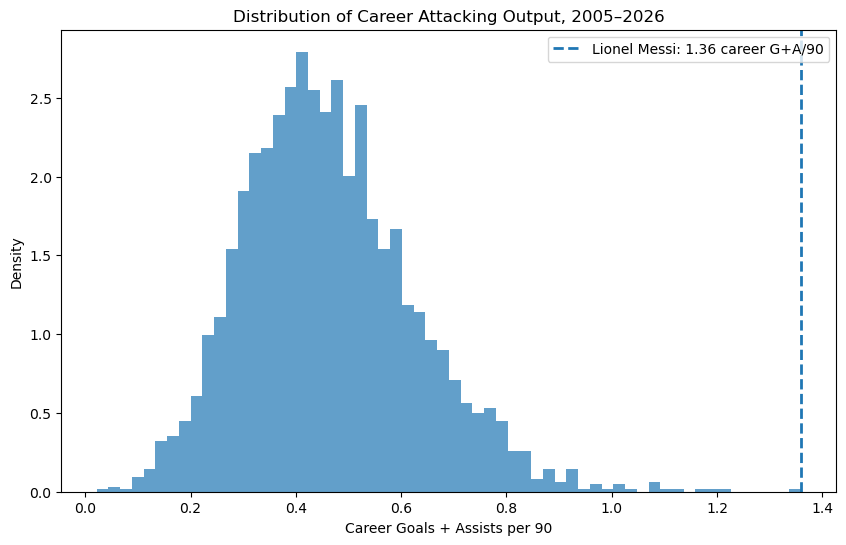

No data found for: Neymar


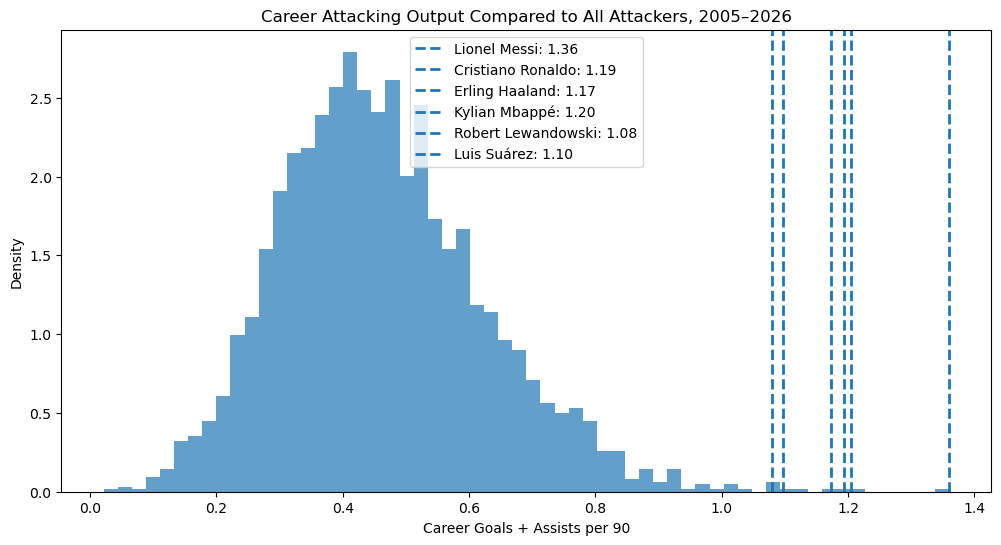


================ PLAYER COMPARISON ================
               Player  First Season  Last Season  Active Seasons  Appearances  \
0        Lionel Messi          2012         2025              12          526   
3       Kylian Mbappé          2015         2025              11          426   
1   Cristiano Ronaldo          2012         2022              11          482   
2      Erling Haaland          2019         2025               7          291   
5         Luis Suárez          2012         2021              10          445   
4  Robert Lewandowski          2012         2025              14          665   

   Minutes  Goals  Assists  G+A  Career G+A per 90   z-score  \
0    44740    452      224  676           1.359857  5.516507   
3    32736    326      112  438           1.204179  4.558747   
1    41150    432      114  546           1.194168  4.497156   
2    23546    255       52  307           1.173448  4.369683   
5    35950    289      149  438           1.096523  3.89642

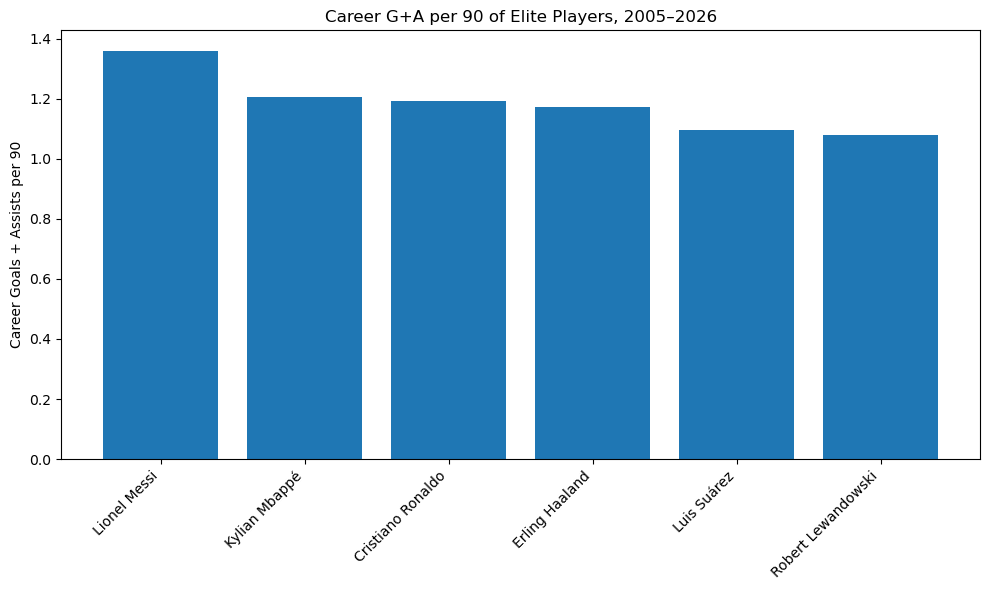


================ TOP 20 CAREER G+A PER 90 ================
                      name position  first_season  last_season  \
2262          Lionel Messi   Attack          2012         2025   
16662        Kylian Mbappé   Attack          2015         2025   
730      Cristiano Ronaldo   Attack          2012         2022   
18978       Erling Haaland   Attack          2019         2025   
192     Zlatan Ibrahimović   Attack          2012         2022   
3638           Luis Suárez   Attack          2012         2021   
26801           Franculino   Attack          2023         2025   
2141         Sergio Agüero   Attack          2012         2020   
3144    Robert Lewandowski   Attack          2012         2025   
16021      Viktor Gyökeres   Attack          2018         2025   
21826       Lassina Traoré   Attack          2018         2025   
20         Claudio Pizarro   Attack          2012         2019   
8913            Harry Kane   Attack          2012         2025   
4154            

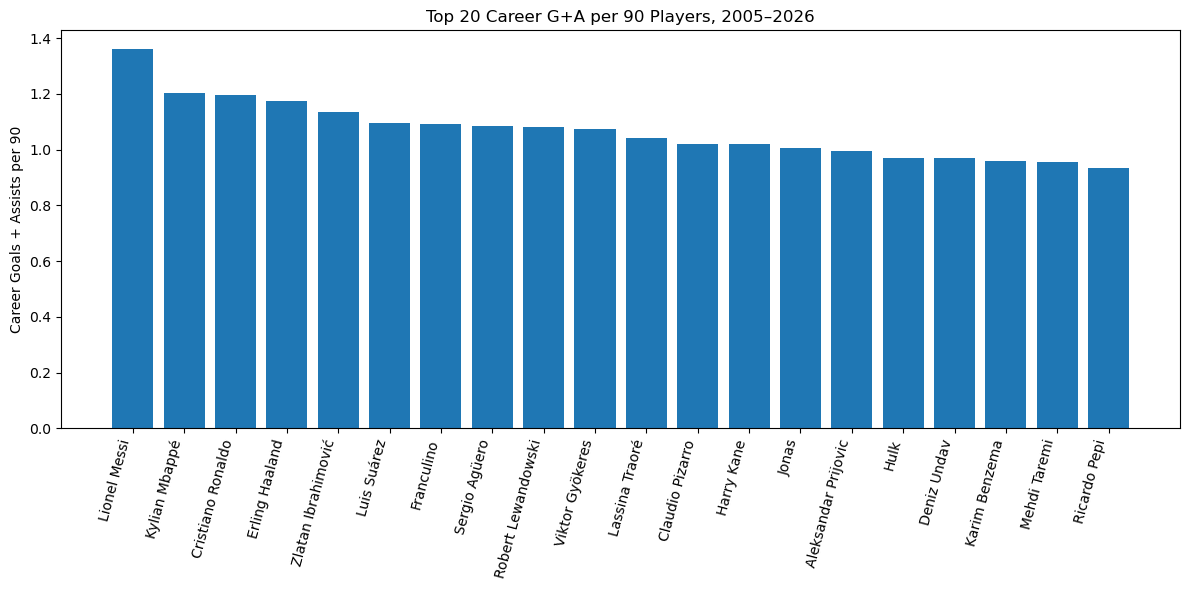

In [5]:

# ============================================================
# 6. AGGREGATE BY PLAYER ACROSS ALL ACTIVE YEARS
# ============================================================

career_stats = df.groupby(
    ["player_id", "name", "position"],
    as_index=False
).agg({
    "goals": "sum",
    "assists": "sum",
    "GA": "sum",
    "minutes_played": "sum",
    "game_id": "count",
    "season": ["min", "max", "nunique"]
})

career_stats.columns = [
    "player_id",
    "name",
    "position",
    "goals",
    "assists",
    "GA",
    "minutes_played",
    "appearances",
    "first_season",
    "last_season",
    "active_seasons"
]

# Remove players with very low total minutes
career_stats = career_stats[career_stats["minutes_played"] >= 3000]

# Calculate career G+A per 90
career_stats["ninety_minutes"] = career_stats["minutes_played"] / 90
career_stats["GA_per90"] = career_stats["GA"] / career_stats["ninety_minutes"]

print("\nCareer-level dataset:")
print(career_stats.head())

print("\nCareer stats shape:", career_stats.shape)


# ============================================================
# 7. FILTER ATTACKERS
# ============================================================

attackers = career_stats[
    career_stats["position"].str.contains(
        "Attack|Forward|Centre-Forward|Winger|Second Striker|Left Winger|Right Winger",
        case=False,
        na=False
    )
].copy()

print("\nAttackers dataset shape:", attackers.shape)

print("\nAttacker positions found:")
print(attackers["position"].value_counts().head(20))


# ============================================================
# 8. FIND ONE PLAYER'S FULL ACTIVE-YEARS RECORD
# ============================================================

player_name = "Messi"

player_rows = attackers[
    attackers["name"].str.contains(player_name, case=False, na=False)
].sort_values("GA_per90", ascending=False)

print(f"\nCareer records found for {player_name}:")
print(
    player_rows[
        [
            "name",
            "position",
            "first_season",
            "last_season",
            "active_seasons",
            "appearances",
            "minutes_played",
            "goals",
            "assists",
            "GA",
            "GA_per90"
        ]
    ]
)


# ============================================================
# 9. CALCULATE CAREER RARITY FOR THAT PLAYER
# ============================================================

if player_rows.empty:
    print(f"\nNo player found matching: {player_name}")
else:
    player_value = player_rows["GA_per90"].iloc[0]
    player_full_name = player_rows["name"].iloc[0]
    first_season = player_rows["first_season"].iloc[0]
    last_season = player_rows["last_season"].iloc[0]
    active_seasons = player_rows["active_seasons"].iloc[0]

    mu = attackers["GA_per90"].mean()
    sd = attackers["GA_per90"].std()

    z = (player_value - mu) / sd

    normal_prob = 1 - norm.cdf(z)
    empirical_prob = (attackers["GA_per90"] >= player_value).mean()

    print("\n================ CAREER RARITY RESULT ================")
    print(f"Player: {player_full_name}")
    print(f"Period covered: {first_season} to {last_season}")
    print(f"Active seasons in dataset: {active_seasons}")
    print(f"Career G+A per 90 = {player_value:.3f}")
    print(f"Dataset mean = {mu:.3f}")
    print(f"Dataset standard deviation = {sd:.3f}")
    print(f"z-score = {z:.2f}σ above average")
    print()

    print(f"Normal probability = {normal_prob:.10f}")
    if normal_prob > 0:
        print(f"Normal rarity ≈ 1 in {1 / normal_prob:,.0f}")

    print()

    print(f"Empirical probability = {empirical_prob:.10f}")
    if empirical_prob > 0:
        print(f"Empirical rarity ≈ 1 in {1 / empirical_prob:,.0f}")


    # ============================================================
    # 10. VISUALIZE CAREER DISTRIBUTION FOR ONE PLAYER
    # ============================================================

    plt.figure(figsize=(10, 6))

    plt.hist(
        attackers["GA_per90"],
        bins=60,
        density=True,
        alpha=0.7
    )

    plt.axvline(
        player_value,
        linestyle="--",
        linewidth=2,
        label=f"{player_full_name}: {player_value:.2f} career G+A/90"
    )

    plt.xlabel("Career Goals + Assists per 90")
    plt.ylabel("Density")
    plt.title("Distribution of Career Attacking Output, 2005–2026")
    plt.legend()
    plt.show()


# ============================================================
# 11. COMPARE MULTIPLE PLAYERS BY FULL ACTIVE-YEARS RECORD
# ============================================================

players_to_compare = [
    "Messi",
    "Cristiano Ronaldo",
    "Haaland",
    "Mbapp",
    "Lewandowski",
    "Neymar",
    "Suárez"
]

plt.figure(figsize=(12, 6))

plt.hist(
    attackers["GA_per90"],
    bins=60,
    density=True,
    alpha=0.7
)

comparison_results = []

for p in players_to_compare:
    rows = attackers[
        attackers["name"].str.contains(p, case=False, na=False)
    ].sort_values("GA_per90", ascending=False)

    if not rows.empty:
        value = rows["GA_per90"].iloc[0]
        full_name = rows["name"].iloc[0]
        first_season = rows["first_season"].iloc[0]
        last_season = rows["last_season"].iloc[0]
        active_seasons = rows["active_seasons"].iloc[0]

        z_score = (value - attackers["GA_per90"].mean()) / attackers["GA_per90"].std()
        empirical_probability = (attackers["GA_per90"] >= value).mean()

        comparison_results.append({
            "Player": full_name,
            "First Season": first_season,
            "Last Season": last_season,
            "Active Seasons": active_seasons,
            "Appearances": rows["appearances"].iloc[0],
            "Minutes": rows["minutes_played"].iloc[0],
            "Goals": rows["goals"].iloc[0],
            "Assists": rows["assists"].iloc[0],
            "G+A": rows["GA"].iloc[0],
            "Career G+A per 90": value,
            "z-score": z_score,
            "Empirical Probability": empirical_probability,
            "Empirical Rarity": f"1 in {1 / empirical_probability:,.0f}" if empirical_probability > 0 else "Undefined"
        })

        plt.axvline(
            value,
            linestyle="--",
            linewidth=2,
            label=f"{full_name}: {value:.2f}"
        )
    else:
        print(f"No data found for: {p}")

plt.xlabel("Career Goals + Assists per 90")
plt.ylabel("Density")
plt.title("Career Attacking Output Compared to All Attackers, 2005–2026")
plt.legend()
plt.show()


# ============================================================
# 12. DISPLAY COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(comparison_results)

print("\n================ PLAYER COMPARISON ================")
print(comparison_df.sort_values("Career G+A per 90", ascending=False))


# ============================================================
# 13. BAR CHART OF ELITE PLAYERS
# ============================================================

if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("Career G+A per 90", ascending=False)

    plt.figure(figsize=(10, 6))

    plt.bar(
        comparison_df["Player"],
        comparison_df["Career G+A per 90"]
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Career Goals + Assists per 90")
    plt.title("Career G+A per 90 of Elite Players, 2005–2026")
    plt.tight_layout()
    plt.show()


# ============================================================
# 14. TOP 20 CAREER G+A PER 90 PLAYERS
# ============================================================

top_20 = attackers.sort_values("GA_per90", ascending=False).head(20)

print("\n================ TOP 20 CAREER G+A PER 90 ================")
print(
    top_20[
        [
            "name",
            "position",
            "first_season",
            "last_season",
            "active_seasons",
            "appearances",
            "minutes_played",
            "goals",
            "assists",
            "GA",
            "GA_per90"
        ]
    ]
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_20["name"],
    top_20["GA_per90"]
)

plt.xticks(rotation=75, ha="right")
plt.ylabel("Career Goals + Assists per 90")
plt.title("Top 20 Career G+A per 90 Players, 2005–2026")
plt.tight_layout()
plt.show()